ENME 618/ENSF 620

$$
\text{Geometric Brownian Motion is a continuous-time stochastic process where the logarithm of the quantity follows a Brownian motion with drift. } \\[10pt]
dS_t = \mu S_t dt + \sigma S_t dW_t \\[10pt]
S_t : \text{asset price at time t} \\
\mu : \text{drift rate (expected annual return)} \\
\sigma : \text{volatility (annual standard deviation of return)} \\
dW_t : \text{increment of Wiener process (Brownian motion) where } dW_t = Z \sqrt{dt} \\
Z ~ N(0,1) 
$$

$$
\text{Analytical solution via Ito's Lemma} \\[10pt]
S_{t+\Delta t} = S_t exp\left(\left(\mu-\frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt(\Delta t) Z\right)
$$

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def getZ():
    while True:
        Z = np.random.standard_normal()
        return Z

def price(S0, mu, sigma, dt):
    Z = getZ()
    S1 = S0 * np.exp((mu-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    return S1

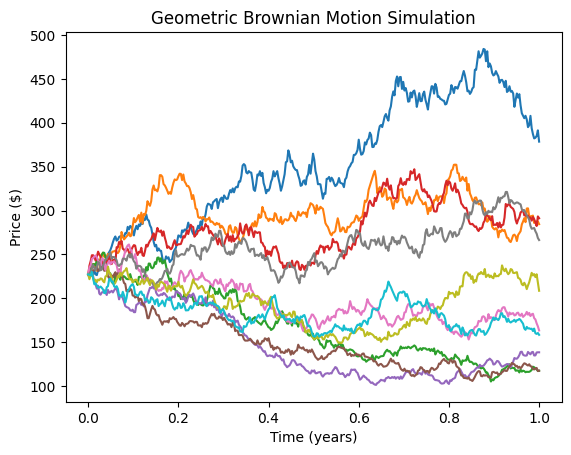

In [13]:
def plot_price(S0, mu, sigma, T, steps, runs):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = np.zeros(len(t))
    s[0] = S0

    fig, ax = plt.subplots()
    for j in range(runs):
        for i in range(1, len(t)):
            s[i] = price(s[i-1], mu, sigma, dt)
        ax.plot(t, s)

    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price ($)')
    ax.set_title('Geometric Brownian Motion Simulation')
    plt.show()

# Values for NVDA stock Sept 21, 2026
# S0 = 227.38  # Current stock price
# K = 240   # Strike price for call option
# K_put = 200  # Strike price for put option
# mu = 0.0444  # Risk-free interest rate 1-year Treasury yield
# sigma = 0.321  # Implied Volatility (IV)
plot_price(227.38, 0.0444, 0.321, 1, 365, 10)

$$
\text{Drift } = \mu-\frac{1}{2}\sigma^2 \\[10pt]
\text{Median price } = S_0 e^{(\mu-\frac{1}{2}\sigma^2) T} \\[10pt]
\text{Expected terminal price } = S_0 e^{\mu T}
$$

In [14]:
def expected_terminal_price(S0, mu, sigma, T):
    tmp = mu-0.5*sigma**2
    median = S0 * np.exp(tmp * T)
    expectation = S0 * np.exp(mu * T)
    return median, expectation

def sim_vs_expected(S0, mu, sigma, T, steps, runs):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = np.zeros((runs, len(t)))
    s[:, 0] = S0

    for j in range(runs):
        for i in range(1, len(t)):
            s[j, i] = price(s[j, i - 1], mu, sigma, dt)
    
    median, expectation = expected_terminal_price(S0, mu, sigma, T)
    print("===== Simulation vs Expected Terminal Price =====")
    print("S0: {}, mu: {}, sigma: {}, T: {}, steps: {}, runs: {} \n".format(S0, mu, sigma, T, steps, runs))
    print(f"Expected median terminal price: {median}")
    print(f"Simulated median terminal price: {np.median(s[:,-1])} \n")
    print(f"Expected mean terminal price: {expectation}")
    print(f"Simulated mean terminal price: {np.mean(s[:,-1])}")
    print("=================================================\n \n")
    
sim_vs_expected(1, 0.05, 0.20, 1, 252, 10000)
sim_vs_expected(1, 0.10, 0.25, 1, 252, 10000)

===== Simulation vs Expected Terminal Price =====
S0: 1, mu: 0.05, sigma: 0.2, T: 1, steps: 252, runs: 10000 

Expected median terminal price: 1.030454533953517
Simulated median terminal price: 1.0358732829095927 

Expected mean terminal price: 1.0512710963760241
Simulated mean terminal price: 1.0536477161835047
 

===== Simulation vs Expected Terminal Price =====
S0: 1, mu: 0.1, sigma: 0.25, T: 1, steps: 252, runs: 10000 

Expected median terminal price: 1.0711683835756507
Simulated median terminal price: 1.0729391024695103 

Expected mean terminal price: 1.1051709180756477
Simulated mean terminal price: 1.1063443861669853
 



$$
\text{Risk-free interest rate (r): US Treasury Bond Yield or Canada Treasury Bond Yield} \\[10pt]
r = 4.44\% \text{ as of Sept 21, 2026 for US Treasury Bond Yield for 1 Year} \\[10pt]
\text{For options pricing, } \mu = r \text{ for a risk-free investment}
$$

In [15]:
def call_option(S0, K, mu, sigma, T, steps, runs):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = np.zeros((runs, len(t)))
    s[:, 0] = S0

    for j in range(runs):
        for i in range(1, len(t)):
            s[j, i] = price(s[j, i - 1], mu, sigma, dt)

    call_payoffs = np.maximum(s[:, -1] - K, 0)
    call_price = np.mean(call_payoffs) * np.exp(-mu * T)
    standard_error = np.std(call_payoffs*np.exp(-mu*T), ddof=1) / np.sqrt(runs)
    return call_price, standard_error

def put_option(S0, K, mu, sigma, T, steps, runs):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = np.zeros((runs, len(t)))
    s[:, 0] = S0

    for j in range(runs):
        for i in range(1, len(t)):
            s[j, i] = price(s[j, i - 1], mu, sigma, dt)

    put_payoffs = np.maximum(K - s[:, -1], 0)
    put_price = np.mean(put_payoffs) * np.exp(-mu * T)
    standard_error = np.std(put_payoffs*np.exp(-mu*T), ddof=1) / np.sqrt(runs)
    return put_price, standard_error

# Values for NVDA stock Sept 21, 2026
# S0 = 227.38  # Current stock price
# K = 240   # Strike price for call option
# K_put = 200  # Strike price for put option
# mu = 0.0444  # Risk-free interest rate 1-year Treasury yield
# sigma = 0.321  # Implied Volatility (IV)
call_price, call_se = call_option(227.38, 240, 0.0444, 0.321, 1, 252, 10000)
put_price, put_se = put_option(227.38, 200, 0.0444, 0.321, 1, 252, 10000)

print("Call Price: {:.4f}".format(call_price))
print("Put Price:  {:.4f}".format(put_price))

Call Price: 28.3399
Put Price:  12.4157


We can compare the options prices we get from the Monte-Carlo simulation of the underlying asset to the analytical solution to the Black-Scholes equation for European options, which assumes a constant volatility $\sigma$. \\[20pt]

$$
\text{Black-Scholes-Merton formula} \\[10pt]
d_1 = \frac{ln(S_0 / K) + (r+\frac{1}{2}\sigma^2)T}{\sigma \sqrt(T)} \\[10pt]
d_2 = d1 - \sigma \sqrt{T} \\[20pt]
\text{European Call Option Price (C)} \\[10pt]
C(S_0,T) = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2) \\[20pt]
\text{European Put Option Price (P)} \\[10pt]
P(S_0,T) = K e^{-rT} \Phi(-d_2) - S_0 \Phi(-d_1) \\[20pt]
\text{where } \Phi(x) \text{ is the cumulative distribution function (CDF) of the standard normal distribution } N(0,1): \\[10pt]
\Phi(x) = \frac{1}{\sqrt(2\pi)} \int_{-\infty}^{x} e^{-\frac{u^2}{2}}du \\[10pt]
\text{ and by symmetry of the normal distribution } \Phi(-x) = 1 - \Phi(x)
$$

$$
\Phi(d_2) = \text{ probability under risk-neutral measure that the option expires in-the-money } Q(S_T > K) \\[10pt]
K e^{-rT} \Phi(d_2) = \text{ present value of expected cash payment to purchase stock at strike K} \\[10pt]
S_0 \Phi(d_1) = \text{ expected present value of stock received at expiration} \\[10pt]
\Phi{d_1} = \text{ Delta $\Delta$ of option contract, i.e. number of shares to dynamically hedge the option} \\[20pt]
\text{Put-Call Parity } : C - P = S_0 - K e^{-rT}
$$

In [16]:
def black_scholes_call(S0, K, mu, sigma, T):
    d1 = (np.log(S0 / K) + (mu + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-mu * T) * norm.cdf(d2)
    return float(call_price)

def black_scholes_put(S0, K, mu, sigma, T):
    d1 = (np.log(S0 / K) + (mu + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-mu * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return float(put_price)

call_price = black_scholes_call(227.38, 240, 0.0444, 0.321, 1)
put_price = black_scholes_put(227.38, 200, 0.0444, 0.321, 1)

print("Call Price: {:.4f}".format(call_price))
print("Put Price:  {:.4f}".format(put_price))

Call Price: 28.0483
Put Price:  12.3907


In [17]:
call_bs = black_scholes_call(227.38, 240, 0.0444, 0.321, 1)
put_bs = black_scholes_put(227.38, 200, 0.0444, 0.321, 1)

call_mc, call_se = call_option(227.38, 240, 0.0444, 0.321, 1, 252, 10000)
put_mc, put_se = put_option(227.38, 200, 0.0444, 0.321, 1, 252, 10000)

# Does the Monte Carlo simulation converge to the Black-Scholes price within 95% confidence interval
print("===== Monte Carlo vs Black-Scholes =====")
print("Monte Carlo Call Price: {:.4f} +/- {:.4f}".format(call_mc,1.96*call_se))
print("Black-Scholes Call Price: {:.4f} \n\n".format(call_bs))

print("Monte Carlo Put Price: {:.4f} +/- {:.4f}".format(put_mc,1.96*put_se))
print("Black-Scholes Put Price: {:.4f} \n".format(put_bs))
print("=========================================\n \n")

===== Monte Carlo vs Black-Scholes =====
Monte Carlo Call Price: 28.4133 +/- 1.0029
Black-Scholes Call Price: 28.0483 


Monte Carlo Put Price: 12.2139 +/- 0.4315
Black-Scholes Put Price: 12.3907 

 



European options contracts can only be exercised at expiration. American options contracts can be exercised at any point before expiration. The price of the contract is now evaluated at time $t < T$

$$
\text{American Options Contract} \\
\text{Value of option } V(S_{t_k},t_k) = max(h(S_{t_k}), C(S_{t_k},t_k)) \\[10pt]
\text{Immediate Exercise Value } h(S_{t_k})\\
\text{Call: } h(S_{t_k}) = max(S_{t_k} - K, 0) \\
\text{Put: } h(S_{t_k}) = max(K - S_{t_k}, 0) \\[10pt]
\text{Continuation Value } C(S_{t_k}, t_k) \\
C(S_{t_k},t_k) = E^Q[e^{-r\Delta t} V(S_{t_{k+1}},t_{k+1}) | S_{t_k}]\\[10pt]
\text{If } h(S_{t_k}) > C(S_{t_k},t_k) \text{ optimal to exercise option immediately} \\
\text{If } h(S_{t_k}) \leq C(S_{t_k},t_k) \text{ optimal to hold option} \\
$$

First though, American options contracts are only optimal to exercise early if the stock itself pays dividends. This will be implemented in the model of the asset through the GBM equation. This can be done continuously, or more accurately as discrete payments. For now, we will model it continuously. 

In [18]:
# q : annual dividend yield
# r : risk-free interest rate
def price_with_dividend(S0, r, q, sigma, dt):
    Z = getZ()
    mu = r - q
    S1 = S0 * np.exp((mu-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    return S1

def monte_carlo_gbm(S0, r, q, sigma, T, steps, runs):
    dt = T / steps
    t = np.linspace(0, T, steps+1)
    s = np.zeros((runs,len(t)))
    s[:,0] = S0
    for i in range(runs):
        for j in range(1, len(t)):
            s[i,j] = price_with_dividend(s[i,j-1], r, q, sigma, dt)
    return s

def call_least_squares_monte_carlo_gbm(S0, K, r, q, sigma, T, steps, runs, poly_degree=2):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = monte_carlo_gbm(S0, r, q, sigma, T, steps, runs)

    h = np.maximum(s - K, 0)  # Immediate Exercise Value, shape (runs, steps+1)

    cash_flow = h[:, -1].copy()          # payoff each path currently realizes
    exercise_time = np.full(runs, T)     # the time at which that payoff occurs

    # Continuation value curve: C(S_{t_k}, t_k) estimated at each timestep
    continuation_curve = np.full((runs, steps + 1), np.nan)

    for j in range(steps - 1, 0, -1):  # walk backwards, skip t=0 (nothing to decide) and t=T (already handled)
        itm = h[:, j] > 0
        if np.sum(itm) > poly_degree:
            discounted_future_cf = cash_flow[itm] * np.exp(-r * (exercise_time[itm] - t[j]))
            coeffs = np.polyfit(s[itm, j], discounted_future_cf, poly_degree)
            C = np.polyval(coeffs, s[itm, j])  # Continuation Value regression estimate
            continuation_curve[itm, j] = C

            exercise_now = h[itm, j] > C
            itm_paths = np.where(itm)[0]
            exercise_idx = itm_paths[exercise_now]

            cash_flow[exercise_idx] = h[exercise_idx, j]
            exercise_time[exercise_idx] = t[j]

    discount_factor = np.exp(-r * exercise_time)  # discount back to t=0
    price = np.mean(cash_flow * discount_factor)
    standard_error = np.std(cash_flow * discount_factor, ddof=1) / np.sqrt(runs)

    return price, standard_error, continuation_curve, s

def put_least_squares_monte_carlo_gbm(S0, K, r, q, sigma, T, steps, runs, poly_degree=2):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s = monte_carlo_gbm(S0, r, q, sigma, T, steps, runs)

    h = np.maximum(K - s, 0)  # Immediate Exercise Value, shape (runs, steps+1)

    cash_flow = h[:, -1].copy()          # payoff each path currently realizes
    exercise_time = np.full(runs, T)     # the time at which that payoff occurs

    # Continuation value curve: C(S_{t_k}, t_k) estimated at each timestep
    c = np.full((runs, steps + 1), np.nan)

    for j in range(steps - 1, 0, -1):  # walk backwards, skip t=0 (nothing to decide) and t=T (already handled)
        itm = h[:, j] > 0
        if np.sum(itm) > poly_degree:
            discounted_future_cf = cash_flow[itm] * np.exp(-r * (exercise_time[itm] - t[j]))
            coeffs = np.polyfit(s[itm, j], discounted_future_cf, poly_degree)
            C = np.polyval(coeffs, s[itm, j])  # Continuation Value regression estimate
            c[itm, j] = C

            exercise_now = h[itm, j] > C
            itm_paths = np.where(itm)[0]
            exercise_idx = itm_paths[exercise_now]

            cash_flow[exercise_idx] = h[exercise_idx, j]
            exercise_time[exercise_idx] = t[j]

    discount_factor = np.exp(-r * exercise_time)  # discount back to t=0
    price = np.mean(cash_flow * discount_factor)
    standard_error = np.std(cash_flow * discount_factor, ddof=1) / np.sqrt(runs)

    return price, standard_error, c, s

put_price, put_se, c, s = put_least_squares_monte_carlo_gbm(227.38, 200, 0.0444, 0.0044, 0.321, 1, 252, 10000)
call_price, call_se, c, s = call_least_squares_monte_carlo_gbm(227.38, 240, 0.0444, 0.0044, 0.321, 1, 252, 10000)
print(f"American Call Price: {call_price:.4f} +/- {1.96*call_se:.4f}")
print(f"American Put Price: {put_price:.4f} +/- {1.96*put_se:.4f}")

American Call Price: 27.3940 +/- 1.0432
American Put Price: 13.6622 +/- 0.4417


$$
\text{Heston Stochastic Volatility Model} \\[20pt]
dS_t = \mu S_t dt + \sqrt{\nu_t} S_t dW_1^t \\
d\nu_t = \kappa (\theta - \nu_t)dt + \xi \sqrt{\nu_t} dW_2^t \\
dW_1^t dW_2^t = \rho dt
$$

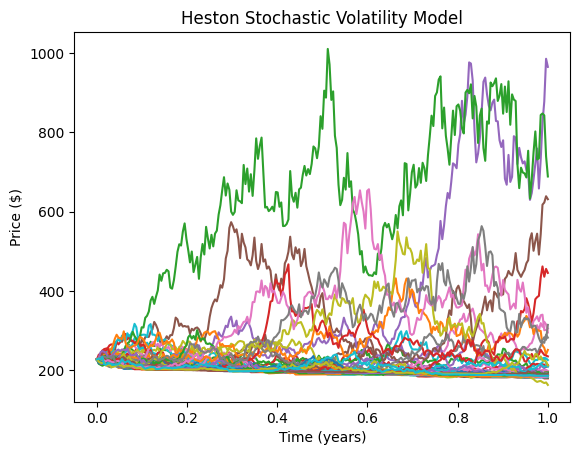

In [19]:
def feller_condition(k, th, xi):
    return 2*k*th > xi**2

def getZ1Z2(rho, runs, steps):
    z1 = np.random.standard_normal((runs, steps))
    z2 = rho * z1 + np.sqrt(1-rho**2) * np.random.standard_normal((runs,steps))
    return z1, z2

# S0 : initial price
# r  : risk free interest rate
# q  : dividend yield
# v0 : variance (v = sigma^2)
# k  : mean reversion speed
# th : long term variance
# xi : volatility of volatility
# rho: correlation
# T  : timeframe
# steps : num trading days in year (252)

def heston_monte_carlo(S0, r, q, v0, k, th, xi, rho, T, steps, runs):

    if feller_condition(k, th, xi):
        dt = T / steps
        z1, z2 = getZ1Z2(rho, runs, steps)

        s = np.zeros((runs,steps+1))
        v = np.zeros((runs,steps+1))

        s[:,0] = S0
        v[:,0] = v0

        for j in range(steps):
            vt = np.maximum(v[:,j],0)

            s[:,j+1] = s[:,j] * np.exp((r-q-0.5*np.maximum(vt,0))*dt + np.sqrt(np.maximum(vt,0)*dt)*z1[:,j])
            v[:,j+1] = v[:,j] + k*(th-v0)*dt + np.sqrt(vt*dt)*z1[:,j]

        return s, v
    else:
        print("Feller condition not satisfied")
        return None, None

T = 1
steps = 252
runs = 50

s, v = heston_monte_carlo(227.38, 0.044, 0.0044, 0.1024, 2.0, 0.16, 0.5, -0.7, T, steps, runs)

fig, ax = plt.subplots()
for i in range(runs):
    ax.plot(np.linspace(0,T,steps+1), s[i,:])
ax.set_title("Heston Stochastic Volatility Model")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Price ($)")
plt.show()

In [20]:
def poly2d_features(s, v, poly_degree=2):
    """Build design matrix of monomials s^i * v^j for i+j <= poly_degree."""
    terms = []
    for total in range(poly_degree + 1):
        for i in range(total + 1):
            j = total - i
            terms.append((s ** i) * (v ** j))
    return np.column_stack(terms)

def fit_continuation_2d(s, v, y, poly_degree=2):
    """Least-squares fit of continuation value as a 2D polynomial in (s, v)."""
    X = poly2d_features(s, v, poly_degree)
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return X @ coeffs

def call_least_squares_monte_carlo_heston(S0, K, r, q, v0, k, th, xi, rho, T, steps, runs, poly_degree=2):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s, v = heston_monte_carlo(S0, r, q, v0, k, th, xi, rho, T, steps, runs)

    h = np.maximum(s - K, 0)  # Immediate Exercise Value, shape (runs, steps+1)

    cash_flow = h[:, -1].copy()          # payoff each path currently realizes
    exercise_time = np.full(runs, T)     # the time at which that payoff occurs

    # Continuation value curve: C(S_{t_k}, v_{t_k}, t_k) estimated at each timestep
    continuation_curve = np.full((runs, steps + 1), np.nan)

    n_features = (poly_degree + 1) * (poly_degree + 2) // 2  # number of s^i*v^j terms with i+j<=poly_degree

    saved_coeffs = {}

    for j in range(steps - 1, 0, -1):  # walk backwards, skip t=0 (nothing to decide) and t=T (already handled)
        itm = h[:, j] > 0
        if np.sum(itm) > n_features:
            discounted_future_cf = cash_flow[itm] * np.exp(-r * (exercise_time[itm] - t[j]))
            C = fit_continuation_2d(s[itm, j], v[itm, j], discounted_future_cf, poly_degree)  # Continuation Value regression estimate
            continuation_curve[itm, j] = C

            exercise_now = h[itm, j] > C
            itm_paths = np.where(itm)[0]
            exercise_idx = itm_paths[exercise_now]

            cash_flow[exercise_idx] = h[exercise_idx, j]
            exercise_time[exercise_idx] = t[j]

    discount_factor = np.exp(-r * exercise_time)  # discount back to t=0
    price = np.mean(cash_flow * discount_factor)
    standard_error = np.std(cash_flow * discount_factor, ddof=1) / np.sqrt(runs)

    return price, standard_error, continuation_curve, s

def put_least_squares_monte_carlo_heston(S0, K, r, q, v0, k, th, xi, rho, T, steps, runs, poly_degree=2):
    dt = T / steps
    t = np.linspace(0, T, steps + 1)
    s, v = heston_monte_carlo(S0, r, q, v0, k, th, xi, rho, T, steps, runs)

    h = np.maximum(K - s, 0)  # Immediate Exercise Value, shape (runs, steps+1)

    cash_flow = h[:, -1].copy()          # payoff each path currently realizes
    exercise_time = np.full(runs, T)     # the time at which that payoff occurs

    # Continuation value curve: C(S_{t_k}, v_{t_k}, t_k) estimated at each timestep
    c = np.full((runs, steps + 1), np.nan)

    n_features = (poly_degree + 1) * (poly_degree + 2) // 2  # number of s^i*v^j terms with i+j<=poly_degree

    for j in range(steps - 1, 0, -1):  # walk backwards, skip t=0 (nothing to decide) and t=T (already handled)
        itm = h[:, j] > 0
        if np.sum(itm) > n_features:
            discounted_future_cf = cash_flow[itm] * np.exp(-r * (exercise_time[itm] - t[j]))
            C = fit_continuation_2d(s[itm, j], v[itm, j], discounted_future_cf, poly_degree)  # Continuation Value regression estimate
            c[itm, j] = C

            exercise_now = h[itm, j] > C
            itm_paths = np.where(itm)[0]
            exercise_idx = itm_paths[exercise_now]

            cash_flow[exercise_idx] = h[exercise_idx, j]
            exercise_time[exercise_idx] = t[j]

    discount_factor = np.exp(-r * exercise_time)  # discount back to t=0
    price = np.mean(cash_flow * discount_factor)
    standard_error = np.std(cash_flow * discount_factor, ddof=1) / np.sqrt(runs)

    return price, standard_error, c, s


T = 1
steps = 252
runs = 10000

call_price, call_se, c, s = call_least_squares_monte_carlo_gbm(227.38, 240, 0.0444, 0.0044, 0.321, T, steps, runs)
call_price_heston, call_se_heston, c_heston, s_heston = call_least_squares_monte_carlo_heston(227.38, 240, 0.044, 0.0044, 0.1024, 2.0, 0.16, 0.5, -0.7, T, steps, runs)

print("=== American Option Contract ===")
print(f"GBM Call Price: {call_price:.4f} +/- {1.96*call_se:.4f}")
print(f"Heston Call Price: {call_price_heston:.4f} +/- {1.96*call_se_heston:.4f}")


=== American Option Contract ===
GBM Call Price: 27.3201 +/- 1.0276
Heston Call Price: 32.1342 +/- 2.3084


To see how the option's fair value decays as expiry approaches, we hold $S_0$, $K$, $r$, $q$, and the Heston parameters fixed, and re-run the Least-Squares Monte Carlo pricer for a decreasing time-to-expiry $\tau$ (as if pricing the same contract on each successive day). This directly gives $V(S_0, \tau)$ from the LSM/Heston simulation itself, without the survivorship bias of trying to extract a value path from a single $T$-maturity run (conditioning on "not yet optimally exercised" skews the surviving paths toward lower payoffs, which is not the same thing as time decay).

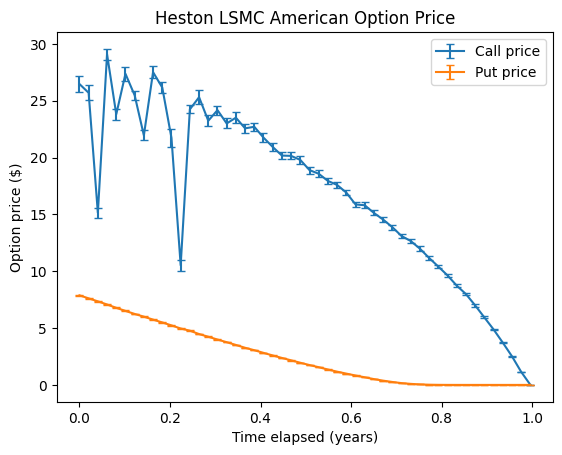

In [22]:
def heston_lsm_price_vs_time_to_expiry(S0, K, r, q, v0, k, th, xi, rho, T, steps_per_year, runs, n_points, poly_degree=2, option="call", asset="gbm"):
    taus = np.linspace(T, T / steps_per_year, n_points)  # avoid tau=0
    prices = np.zeros(n_points)
    errors = np.zeros(n_points)

    if (asset == "gbm"):
        pricer = call_least_squares_monte_carlo_gbm if option == "call" else put_least_squares_monte_carlo_gbm
    else:
        pricer = call_least_squares_monte_carlo_heston if option == "call" else put_least_squares_monte_carlo_heston

    for i, tau in enumerate(taus):
        steps = max(2, int(round(steps_per_year * tau)))
        price, se, _, _ = pricer(S0, K, r, q, v0, k, th, xi, rho, tau, steps, runs, poly_degree)
        prices[i] = price
        errors[i] = se

    return taus, prices, errors

# Fewer runs/timesteps than the single full-T pricing above, since this repeats the
# whole LSM simulation at each time-to-expiry point.
runs_decay = 100000
n_points = 50

tau_call, call_prices_over_time, call_se_over_time = heston_lsm_price_vs_time_to_expiry(227.38, 240, 0.044, 0.0044, 0.1024, 2.0, 0.16, 0.5, -0.7, T, steps, runs_decay, n_points, option="call",asset="heston")
tau_put, put_prices_over_time, put_se_over_time = heston_lsm_price_vs_time_to_expiry(227.38, 200, 0.044, 0.0044, 0.1024, 2.0, 0.16, 0.5, -0.7, T, steps, runs_decay, n_points, option="put",asset="heston")

time_elapsed_call = T - tau_call
time_elapsed_put = T - tau_put

fig, ax = plt.subplots()
ax.errorbar(time_elapsed_call, call_prices_over_time, yerr=1.96 * call_se_over_time, label="Call price", capsize=3)
ax.errorbar(time_elapsed_put, put_prices_over_time, yerr=1.96 * put_se_over_time, label="Put price", capsize=3)
ax.set_xlabel("Time elapsed (years)")
ax.set_ylabel("Option price ($)")
ax.set_title("Heston LSMC American Option Price")
ax.legend()
plt.show()